## Model Ablation Comparison: U-Net+FiLM vs U-FNO

This notebook runs the same ablation study on both final models side by side,
to directly explain why U-Net+FiLM excels at direction and U-FNO excels at intensity.

**Prerequisite:** Trained checkpoints for both models (`unet_film_best_wp.pt`, `ufno_best_wp.pt`).

- **Input:** Processed data from `data/processed-data/` and model checkpoints from `checkpoints/`.
- **Ablation types:** Modality-level (grid/env/1D), grid channel groups (leave-one-out),
  env feature groups (leave-one-out).

### Notebook Sections
0. Setup & Configuration
1. Model Definitions
2. Data Loading & Model Instantiation
3. Evaluation & Ablation Infrastructure
4. Baseline Evaluation
5. Modality Ablation
6. Grid Channel Group Ablation (Leave-One-Out)
7. Env Feature Group Ablation (Leave-One-Out)
8. Summary Table
9. SHAP Analysis on Env Features
10. Gradient-Based Grid Channel Attribution

## Section 0: Setup & Configuration

In [14]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import OrderedDict
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'main-analysis.ipynb').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed-data'
CKPT_DIR = PROJECT_ROOT / 'checkpoints'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR} (exists: {DATA_DIR.exists()})')
print(f'Checkpoint dir: {CKPT_DIR} (exists: {CKPT_DIR.exists()})')
print(f'Device: {DEVICE}')

Project root: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting
Data dir:     /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data (exists: True)
Checkpoint dir: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/checkpoints (exists: True)
Device: cuda


## Section 1: Model Definitions

Both model classes are copied from their respective training notebooks
to ensure exact architecture match with the saved checkpoints.

In [15]:
# ============================================================
# U-Net + FiLM model (matches checkpoint structure exactly)
# ============================================================

class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation. Identity-init (gamma=1, beta=0)."""
    def __init__(self, cond_dim, channels):
        super().__init__()
        self.fc = nn.Linear(cond_dim, channels * 2)
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
        self.fc.bias.data[:channels] = 1.0
    def forward(self, x, cond):
        gamma, beta = self.fc(cond).chunk(2, dim=1)
        return gamma.unsqueeze(-1).unsqueeze(-1) * x + beta.unsqueeze(-1).unsqueeze(-1)

class ConvBlock(nn.Module):
    """Double conv with residual + FiLM after second BN."""
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.film = FiLMLayer(cond_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = self.act(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        h = self.film(h, cond)
        h = self.act(h)
        return h + self.residual(x)

class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch // r, 4)), nn.GELU(),
            nn.Linear(max(ch // r, 4), ch), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class UNetFiLM2dClassifier(nn.Module):
    """U-Net with FiLM time conditioning - flat structure matching checkpoint."""
    def __init__(self, in_channels=15, base_channels=48, n_levels=3,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, time_dim=6, time_emb_dim=64,
                 use_env=True, use_1d=True, head_dim=512):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.n_levels = n_levels

        # Time embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim))

        # Encoder (flat ModuleLists)
        self.encoders = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        ch = in_channels
        for i in range(n_levels):
            out = base_channels * (2 ** i)
            self.encoders.append(ConvBlock(ch, out, time_emb_dim))
            self.se_blocks.append(SEBlock(out))
            ch = out

        # Bottleneck
        bneck = base_channels * (2 ** n_levels)
        self.bottleneck = ConvBlock(ch, bneck, time_emb_dim)

        # Decoder (flat ModuleLists)
        self.ups = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = bneck
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.ups.append(nn.ConvTranspose2d(ch, ch, 2, stride=2))
            self.decoders.append(ConvBlock(ch + skip_ch, skip_ch, time_emb_dim))
            ch = skip_ch

        # Classification heads
        self.gap = nn.AdaptiveAvgPool2d(1)
        fuse = base_channels + (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        self.head_dir = nn.Sequential(
            nn.Linear(fuse, head_dim), nn.GELU(), nn.Dropout(0.0),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.0),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(fuse, head_dim), nn.GELU(), nn.Dropout(0.0),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.0),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat)
        skips, x = [], grid
        for enc, se in zip(self.encoders, self.se_blocks):
            x = enc(x, t)
            x = se(x)
            skips.append(x)
            x = F.max_pool2d(x, 2, ceil_mode=True)
        x = self.bottleneck(x, t)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            dh, dw = x.size(2) - skip.size(2), x.size(3) - skip.size(3)
            if dh > 0 or dw > 0:
                x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
            elif dh < 0 or dw < 0:
                x = F.pad(x, [0, -dw, 0, -dh])
            x = dec(torch.cat([x, skip], 1), t)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        f = torch.cat(parts, 1)
        return self.head_dir(f), self.head_int(f)

print('U-Net+FiLM model defined.')

U-Net+FiLM model defined.


In [16]:
# ============================================================
# U-FNO model (matches checkpoint structure exactly)
# ============================================================

class SpectralConv2d(nn.Module):
    """2D Fourier spectral conv with reflect padding."""
    def __init__(self, in_ch, out_ch, modes1, modes2, padding=9):
        super().__init__()
        self.modes1, self.modes2, self.out_channels, self.padding = modes1, modes2, out_ch, padding
        s = (2/(in_ch+out_ch))**0.5
        self.w1 = nn.Parameter(s*(torch.rand(in_ch,out_ch,modes1,modes2,dtype=torch.cfloat)-0.5))
        self.w2 = nn.Parameter(s*(torch.rand(in_ch,out_ch,modes1,modes2,dtype=torch.cfloat)-0.5))
    def forward(self, x):
        B,C,H,W = x.shape
        if self.padding > 0:
            x = F.pad(x, [self.padding]*4, mode='reflect')
        Hp,Wp = x.shape[-2], x.shape[-1]
        xf = torch.fft.rfft2(x)
        of = torch.zeros(B,self.out_channels,Hp,Wp//2+1,dtype=torch.cfloat,device=x.device)
        of[:,:,:self.modes1,:self.modes2] = torch.einsum('bixy,ioxy->boxy',xf[:,:,:self.modes1,:self.modes2],self.w1)
        of[:,:,-self.modes1:,:self.modes2] = torch.einsum('bixy,ioxy->boxy',xf[:,:,-self.modes1:,:self.modes2],self.w2)
        x = torch.fft.irfft2(of, s=(Hp,Wp))
        if self.padding > 0:
            x = x[:,:,self.padding:-self.padding,self.padding:-self.padding]
        return x

class UNetBranch(nn.Module):
    """Lightweight single-level U-Net branch for local features."""
    def __init__(self, ch):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(ch,ch,3,stride=2,padding=1,bias=False), nn.BatchNorm2d(ch), nn.GELU())
        self.mid = nn.Sequential(nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.BatchNorm2d(ch), nn.GELU())
        self.up = nn.ConvTranspose2d(ch,ch,2,stride=2)
        self.fuse = nn.Sequential(nn.Conv2d(ch*2,ch,1,bias=False), nn.BatchNorm2d(ch))
    def forward(self, x):
        skip = x
        x = self.down(x); x = self.mid(x); x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], 1))

class FiLMLayerFNO(nn.Module):
    def __init__(self, cond_dim, ch):
        super().__init__()
        self.fc = nn.Linear(cond_dim, ch*2)
        nn.init.zeros_(self.fc.weight); nn.init.zeros_(self.fc.bias)
        self.fc.bias.data[:ch] = 1.0
    def forward(self, x, c):
        g,b = self.fc(c).chunk(2,1)
        return g.unsqueeze(-1).unsqueeze(-1)*x + b.unsqueeze(-1).unsqueeze(-1)

class Gate(nn.Module):
    """Learnable softmax gate for 3 branches."""
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.ones(3) / 3)
    def forward(self):
        return F.softmax(self.w, dim=0)

class UFNOBlock(nn.Module):
    """U-FNO block: 3 gated branches (spectral + unet + residual) + FiLM."""
    def __init__(self, ch, modes, padding, time_emb_dim, dropout=0.1):
        super().__init__()
        self.spectral = SpectralConv2d(ch, ch, modes, modes, padding)
        self.unet = UNetBranch(ch)
        self.residual = nn.Conv2d(ch, ch, 1)
        self.gate = Gate()
        self.norm = nn.BatchNorm2d(ch)
        self.film = FiLMLayerFNO(time_emb_dim, ch)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x, t_emb):
        g = self.gate()
        out = g[0]*self.spectral(x) + g[1]*self.unet(x) + g[2]*self.residual(x)
        out = self.norm(out)
        if t_emb is not None:
            out = self.film(out, t_emb)
        out = self.dropout(F.gelu(out))
        return out + x

class UFNO2dClassifier(nn.Module):
    """U-FNO with FiLM time conditioning - matches checkpoint."""
    def __init__(self, in_ch=15, hidden_ch=48, n_modes=16, n_layers=2, padding=9,
                 n_dir=8, n_int=4, env_dim=40, d1d_dim=4,
                 use_env=True, use_1d=True, time_dim=6, time_emb_dim=64, dropout=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.time_mlp = nn.Sequential(nn.Linear(time_dim,time_emb_dim),nn.GELU(),nn.Linear(time_emb_dim,time_emb_dim))
        self.lifting = nn.Sequential(nn.Conv2d(in_ch,hidden_ch,1),nn.GELU())
        self.blocks = nn.ModuleList([UFNOBlock(hidden_ch,n_modes,padding,time_emb_dim,dropout) for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(hidden_ch,hidden_ch,1),nn.GELU())
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = hidden_ch + aux
        self.head_dir = nn.Sequential(nn.Linear(h_in,128),nn.GELU(),nn.Dropout(0.2),
                                       nn.Linear(128,64),nn.GELU(),nn.Dropout(0.1),nn.Linear(64,n_dir))
        self.head_int = nn.Sequential(nn.Linear(h_in,128),nn.GELU(),nn.Dropout(0.2),
                                       nn.Linear(128,64),nn.GELU(),nn.Dropout(0.1),nn.Linear(64,n_int))
    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat) if time_feat is not None else None
        x = self.lifting(grid)
        for blk in self.blocks: x = blk(x, t)
        x = self.proj(x).mean(dim=(-2,-1))
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, -1)
        return self.head_dir(x), self.head_int(x)

print('U-FNO model defined.')

U-FNO model defined.


## Section 2: Data Loading & Model Instantiation

In [17]:
# - Dataset -
class CycloneDataset(Dataset):
    """Timestep-level samples with time features. Returns 6-tuple."""
    def __init__(self, grids, env, data1d, labels, time_feats,
                 use_reflected=False, d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = 'direction_reflected' if use_reflected else 'direction'
        for storm_id in grids:
            g, e, d, t = grids[storm_id], env[storm_id], data1d[storm_id], time_feats[storm_id]
            d_lbl, i_lbl = labels[storm_id][dir_key], labels[storm_id]['intensity']
            for idx in range(g.shape[0]):
                if d_lbl[idx].item() == -1 or i_lbl[idx].item() == -1:
                    continue
                self.samples.append((g[idx], e[idx], d[idx], t[idx],
                                     d_lbl[idx].long(), i_lbl[idx].long()))
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(0)
            self.d1d_std  = all_1d.std(0).clamp(min=1e-6)
        else:
            self.d1d_mean, self.d1d_std = d1d_mean, d1d_std
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        grid, env, d1d, tf, dl, il = self.samples[idx]
        return grid, env, (d1d - self.d1d_mean) / self.d1d_std, tf, dl, il

# - Load data -
def load_split(split):
    return (
        torch.load(DATA_DIR / 'grids'  / f'{split}_grids.pt',  weights_only=False),
        torch.load(DATA_DIR / 'env'    / f'{split}_env.pt',    weights_only=False),
        torch.load(DATA_DIR / 'data1d' / f'{split}_1d.pt',     weights_only=False),
        torch.load(DATA_DIR / 'labels' / f'{split}_labels.pt', weights_only=False),
        torch.load(DATA_DIR / 'time'   / f'{split}_time.pt',   weights_only=False),
    )

train_data = load_split('wp_train')
val_data   = load_split('wp_val')

ds_train = CycloneDataset(*train_data)
ds_val   = CycloneDataset(*val_data, d1d_mean=ds_train.d1d_mean, d1d_std=ds_train.d1d_std)

val_loader = DataLoader(ds_val, batch_size=64, shuffle=False, num_workers=0)
print(f'WP val samples: {len(ds_val)}')

# - Load models -
unet_film = UNetFiLM2dClassifier().to(DEVICE)
unet_film.load_state_dict(torch.load(CKPT_DIR / 'unet_film_best_wp.pt', weights_only=False, map_location=DEVICE))
unet_film.eval()
print(f'U-Net+FiLM loaded: {sum(p.numel() for p in unet_film.parameters())/1e6:.1f}M params')

ufno = UFNO2dClassifier().to(DEVICE)
ufno.load_state_dict(torch.load(CKPT_DIR / 'ufno_best_wp.pt', weights_only=False, map_location=DEVICE))
ufno.eval()
print(f'U-FNO loaded: {sum(p.numel() for p in ufno.parameters())/1e6:.1f}M params')

WP val samples: 535
U-Net+FiLM loaded: 5.9M params
U-FNO loaded: 2.5M params


## Section 3: Evaluation & Ablation Infrastructure

In [18]:
@torch.no_grad()
def evaluate(model, loader, mask_fn=None):
    """Evaluate model with optional input masking.
    mask_fn: callable(grid, env, d1d, time_feat) -> (grid, env, d1d, time_feat)
    """
    model.eval()
    dp, dt, ip, it_ = [], [], [], []
    for grid, env, d1d, tf, dl, il in loader:
        grid, env, d1d, tf = grid.to(DEVICE), env.to(DEVICE), d1d.to(DEVICE), tf.to(DEVICE)
        if mask_fn is not None:
            grid, env, d1d, tf = mask_fn(grid, env, d1d, tf)
        d_out, i_out = model(grid, env, d1d, tf)
        dp.extend(d_out.argmax(1).cpu().tolist()); dt.extend(dl.tolist())
        ip.extend(i_out.argmax(1).cpu().tolist()); it_.extend(il.tolist())
    return {
        'dir_acc': accuracy_score(dt, dp),
        'dir_f1':  f1_score(dt, dp, average='macro', zero_division=0),
        'int_acc': accuracy_score(it_, ip),
        'int_f1':  f1_score(it_, ip, average='macro', zero_division=0),
    }

# - Ablation groups -
GRID_GROUPS = OrderedDict({
    'SST':           [0],
    'u_wind':        [1, 2, 3, 4],
    'v_wind':        [5, 6, 7, 8],
    'geopotential':  [9, 10, 11, 12],
    'wind_shear':    [13],
    'vorticity':     [14],
})

ENV_GROUPS = OrderedDict({
    'wind':            slice(0, 1),
    'move_velocity':   slice(1, 2),
    'intensity_class': slice(2, 8),
    'month':           slice(8, 20),
    'history_dir_12h': slice(20, 28),
    'history_dir_24h': slice(28, 36),
    'history_int_24h': slice(36, 40),
})

# - Mask factories -
def mask_no_grid(g, e, d, t):   return torch.zeros_like(g), e, d, t
def mask_no_env(g, e, d, t):    return g, torch.zeros_like(e), d, t
def mask_no_d1d(g, e, d, t):    return g, e, torch.zeros_like(d), t
def mask_no_time(g, e, d, t):   return g, e, d, torch.zeros_like(t)
def mask_only_grid(g, e, d, t): return g, torch.zeros_like(e), torch.zeros_like(d), t
def mask_only_env(g, e, d, t):  return torch.zeros_like(g), e, torch.zeros_like(d), t
def mask_only_d1d(g, e, d, t):  return torch.zeros_like(g), torch.zeros_like(e), d, t

MODALITY_CONFIGS = OrderedDict({
    'No Grid':   mask_no_grid,
    'No Env':    mask_no_env,
    'No 1D':     mask_no_d1d,
    'No Time':   mask_no_time,
    'Only Grid': mask_only_grid,
    'Only Env':  mask_only_env,
    'Only 1D':   mask_only_d1d,
})

print('Evaluation and ablation infrastructure ready.')

Evaluation and ablation infrastructure ready.


## Section 4: Baseline Evaluation

Evaluate both models with all inputs present (no masking) to establish the baseline accuracy.

In [19]:
baseline_unet = evaluate(unet_film, val_loader)
baseline_ufno = evaluate(ufno, val_loader)

print(f'{"Metric":>15s}  {"U-Net+FiLM":>12s}  {"U-FNO":>12s}')
print('-' * 45)
for k in ['dir_acc', 'dir_f1', 'int_acc', 'int_f1']:
    print(f'{k:>15s}  {baseline_unet[k]:12.4f}  {baseline_ufno[k]:12.4f}')

         Metric    U-Net+FiLM         U-FNO
---------------------------------------------
        dir_acc        0.5645        0.5570
         dir_f1        0.4041        0.4036
        int_acc        0.5738        0.6299
         int_f1        0.4719        0.4928


## Section 5: Modality Ablation

Zero out entire input modalities to measure how much each model
depends on grid, env, 1D, and temporal features.

In [20]:
modality_results = {}

for name, mask_fn in MODALITY_CONFIGS.items():
    r_unet = evaluate(unet_film, val_loader, mask_fn=mask_fn)
    r_ufno = evaluate(ufno, val_loader, mask_fn=mask_fn)
    modality_results[name] = {'unet': r_unet, 'ufno': r_ufno}
    print(f'{name:>12s}  |  U-Net dir_acc={r_unet["dir_acc"]:.3f} '
          f'(drop {baseline_unet["dir_acc"]-r_unet["dir_acc"]:+.3f})  '
          f'int_acc={r_unet["int_acc"]:.3f} '
          f'(drop {baseline_unet["int_acc"]-r_unet["int_acc"]:+.3f})')
    print(f'{"":>12s}  |  U-FNO dir_acc={r_ufno["dir_acc"]:.3f} '
          f'(drop {baseline_ufno["dir_acc"]-r_ufno["dir_acc"]:+.3f})  '
          f'int_acc={r_ufno["int_acc"]:.3f} '
          f'(drop {baseline_ufno["int_acc"]-r_ufno["int_acc"]:+.3f})')
    print()

     No Grid  |  U-Net dir_acc=0.323 (drop +0.241)  int_acc=0.385 (drop +0.189)
              |  U-FNO dir_acc=0.329 (drop +0.228)  int_acc=0.393 (drop +0.237)

      No Env  |  U-Net dir_acc=0.550 (drop +0.015)  int_acc=0.503 (drop +0.071)
              |  U-FNO dir_acc=0.555 (drop +0.002)  int_acc=0.591 (drop +0.039)

       No 1D  |  U-Net dir_acc=0.587 (drop -0.022)  int_acc=0.600 (drop -0.026)
              |  U-FNO dir_acc=0.550 (drop +0.007)  int_acc=0.613 (drop +0.017)

     No Time  |  U-Net dir_acc=0.557 (drop +0.007)  int_acc=0.521 (drop +0.052)
              |  U-FNO dir_acc=0.566 (drop -0.009)  int_acc=0.561 (drop +0.069)

   Only Grid  |  U-Net dir_acc=0.583 (drop -0.019)  int_acc=0.521 (drop +0.052)
              |  U-FNO dir_acc=0.551 (drop +0.006)  int_acc=0.557 (drop +0.073)

    Only Env  |  U-Net dir_acc=0.305 (drop +0.260)  int_acc=0.383 (drop +0.191)
              |  U-FNO dir_acc=0.333 (drop +0.224)  int_acc=0.310 (drop +0.320)

     Only 1D  |  U-Net dir_acc=0.2

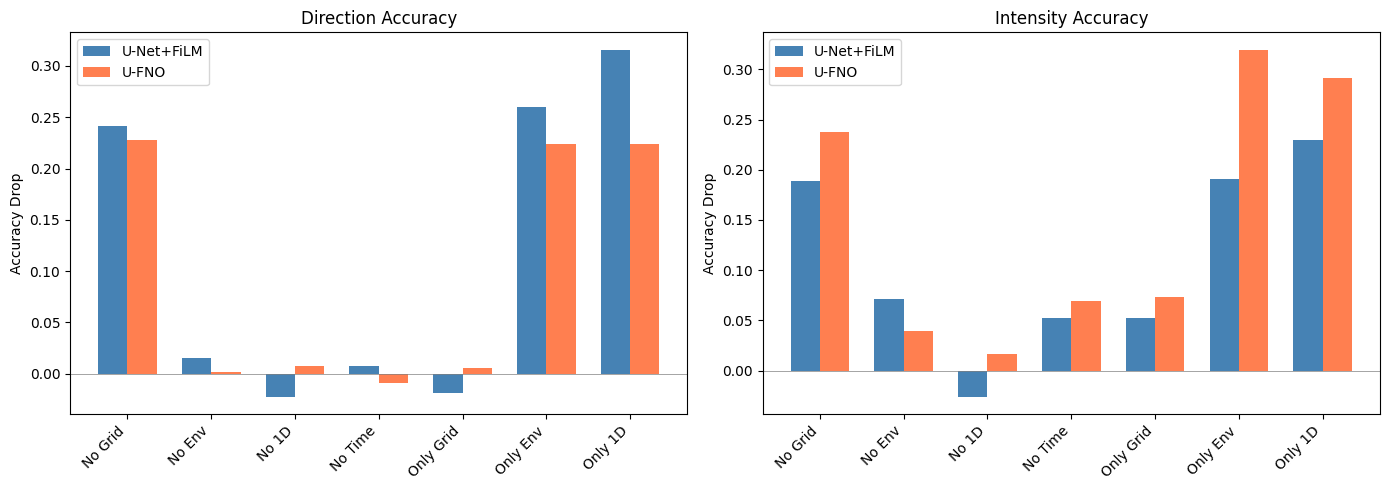

Saved: figures/ablation_modality_comparison.png


In [21]:
# - Modality ablation comparison plot -
configs = list(MODALITY_CONFIGS.keys())
metrics = ['dir_acc', 'int_acc']
titles = ['Direction Accuracy', 'Intensity Accuracy']
baselines = [baseline_unet, baseline_ufno]
labels = ['U-Net+FiLM', 'U-FNO']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(configs))
w = 0.35

for ax, metric, title in zip(axes, metrics, titles):
    unet_drops = [baselines[0][metric] - modality_results[c]['unet'][metric] for c in configs]
    ufno_drops = [baselines[1][metric] - modality_results[c]['ufno'][metric] for c in configs]
    ax.bar(x - w/2, unet_drops, w, label='U-Net+FiLM', color='steelblue')
    ax.bar(x + w/2, ufno_drops, w, label='U-FNO', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(configs, rotation=45, ha='right')
    ax.set_ylabel('Accuracy Drop'); ax.set_title(title)
    ax.legend(); ax.axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'ablation_modality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_modality_comparison.png')

## Section 6: Grid Channel Group Ablation (Leave-One-Out)

Zero out one grid channel group at a time to see which atmospheric
variables each model relies on most.

In [22]:
grid_results = {}

for group_name, channels in GRID_GROUPS.items():
    def make_mask(chs):
        def mask_fn(g, e, d, t):
            g2 = g.clone(); g2[:, chs, :, :] = 0.0
            return g2, e, d, t
        return mask_fn
    r_unet = evaluate(unet_film, val_loader, mask_fn=make_mask(channels))
    r_ufno = evaluate(ufno, val_loader, mask_fn=make_mask(channels))
    grid_results[group_name] = {'unet': r_unet, 'ufno': r_ufno}
    print(f'Drop {group_name:15s}  |  U-Net dir={baseline_unet["dir_acc"]-r_unet["dir_acc"]:+.4f} '
          f'int={baseline_unet["int_acc"]-r_unet["int_acc"]:+.4f}  |  '
          f'U-FNO dir={baseline_ufno["dir_acc"]-r_ufno["dir_acc"]:+.4f} '
          f'int={baseline_ufno["int_acc"]-r_ufno["int_acc"]:+.4f}')

Drop SST              |  U-Net dir=+0.0000 int=+0.0430  |  U-FNO dir=+0.0206 int=+0.0505
Drop u_wind           |  U-Net dir=+0.2056 int=+0.0037  |  U-FNO dir=+0.0561 int=+0.0037
Drop v_wind           |  U-Net dir=+0.1009 int=+0.0187  |  U-FNO dir=+0.0692 int=+0.0168
Drop geopotential     |  U-Net dir=-0.0037 int=-0.0112  |  U-FNO dir=-0.0112 int=-0.0187
Drop wind_shear       |  U-Net dir=+0.0037 int=+0.0075  |  U-FNO dir=+0.0112 int=+0.0112
Drop vorticity        |  U-Net dir=-0.0037 int=+0.0037  |  U-FNO dir=+0.0112 int=-0.0037


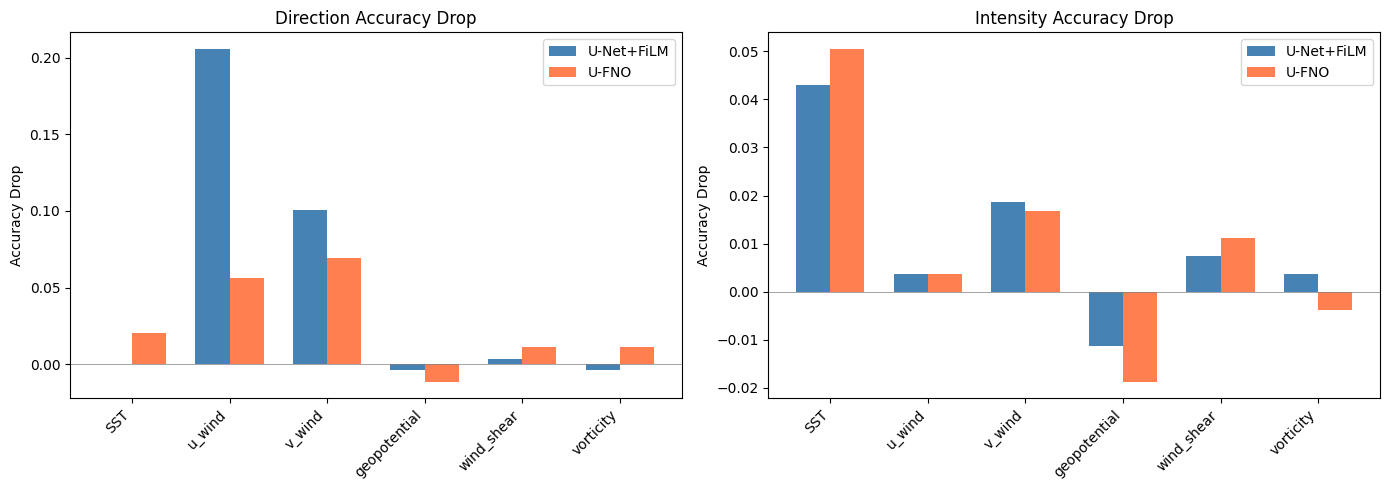

Saved: figures/ablation_grid_comparison.png


In [23]:
# - Grid channel group ablation comparison plot -
groups = list(GRID_GROUPS.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(groups))
w = 0.35

for ax, metric, title in zip(axes, ['dir_acc', 'int_acc'], ['Direction Accuracy Drop', 'Intensity Accuracy Drop']):
    unet_drops = [baseline_unet[metric] - grid_results[g]['unet'][metric] for g in groups]
    ufno_drops = [baseline_ufno[metric] - grid_results[g]['ufno'][metric] for g in groups]
    ax.bar(x - w/2, unet_drops, w, label='U-Net+FiLM', color='steelblue')
    ax.bar(x + w/2, ufno_drops, w, label='U-FNO', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(groups, rotation=45, ha='right')
    ax.set_ylabel('Accuracy Drop'); ax.set_title(title)
    ax.legend(); ax.axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'ablation_grid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_grid_comparison.png')

## Section 7: Env Feature Group Ablation (Leave-One-Out)

Zero out one environmental feature group at a time.

In [24]:
env_results = {}

for group_name, slc in ENV_GROUPS.items():
    def make_mask(s):
        def mask_fn(g, e, d, t):
            e2 = e.clone(); e2[:, s] = 0.0
            return g, e2, d, t
        return mask_fn
    r_unet = evaluate(unet_film, val_loader, mask_fn=make_mask(slc))
    r_ufno = evaluate(ufno, val_loader, mask_fn=make_mask(slc))
    env_results[group_name] = {'unet': r_unet, 'ufno': r_ufno}
    print(f'Drop {group_name:18s}  |  U-Net dir={baseline_unet["dir_acc"]-r_unet["dir_acc"]:+.4f} '
          f'int={baseline_unet["int_acc"]-r_unet["int_acc"]:+.4f}  |  '
          f'U-FNO dir={baseline_ufno["dir_acc"]-r_ufno["dir_acc"]:+.4f} '
          f'int={baseline_ufno["int_acc"]-r_ufno["int_acc"]:+.4f}')

Drop wind                |  U-Net dir=+0.0019 int=-0.0037  |  U-FNO dir=+0.0056 int=-0.0093
Drop move_velocity       |  U-Net dir=+0.0000 int=-0.0019  |  U-FNO dir=-0.0019 int=+0.0000
Drop intensity_class     |  U-Net dir=+0.0056 int=-0.0056  |  U-FNO dir=+0.0037 int=-0.0075
Drop month               |  U-Net dir=-0.0056 int=-0.0037  |  U-FNO dir=+0.0000 int=+0.0168
Drop history_dir_12h     |  U-Net dir=+0.0037 int=+0.0056  |  U-FNO dir=+0.0112 int=+0.0019
Drop history_dir_24h     |  U-Net dir=-0.0056 int=+0.0075  |  U-FNO dir=+0.0019 int=-0.0037
Drop history_int_24h     |  U-Net dir=-0.0112 int=+0.0299  |  U-FNO dir=+0.0056 int=+0.0075


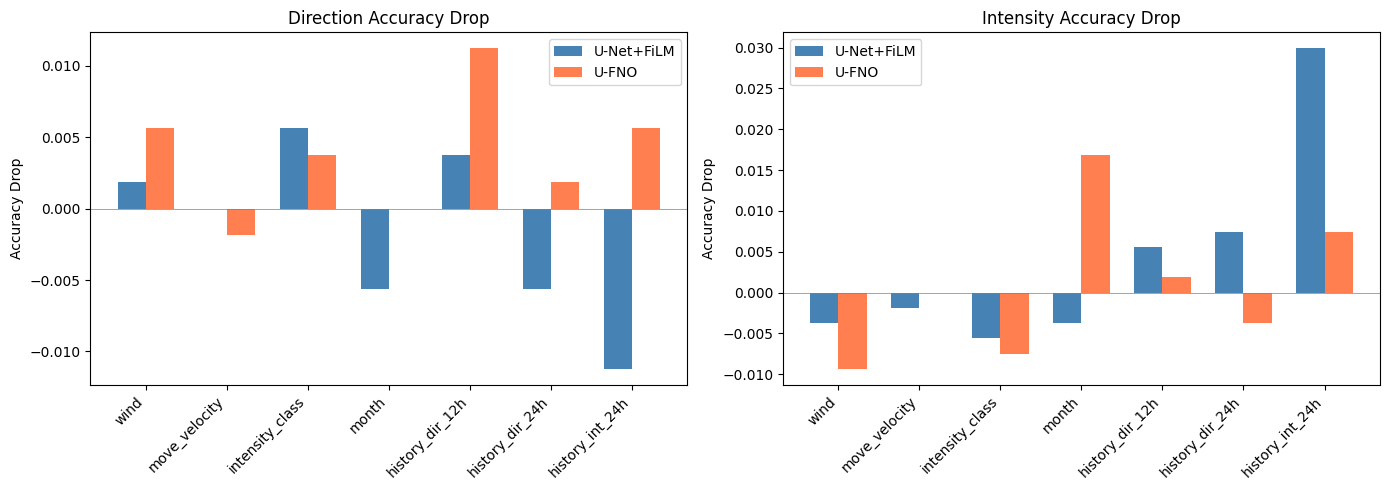

Saved: figures/ablation_env_comparison.png


In [25]:
# - Env feature group ablation comparison plot -
env_names = list(ENV_GROUPS.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(env_names))
w = 0.35

for ax, metric, title in zip(axes, ['dir_acc', 'int_acc'], ['Direction Accuracy Drop', 'Intensity Accuracy Drop']):
    unet_drops = [baseline_unet[metric] - env_results[g]['unet'][metric] for g in env_names]
    ufno_drops = [baseline_ufno[metric] - env_results[g]['ufno'][metric] for g in env_names]
    ax.bar(x - w/2, unet_drops, w, label='U-Net+FiLM', color='steelblue')
    ax.bar(x + w/2, ufno_drops, w, label='U-FNO', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(env_names, rotation=45, ha='right')
    ax.set_ylabel('Accuracy Drop'); ax.set_title(title)
    ax.legend(); ax.axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'ablation_env_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_env_comparison.png')

## Section 8: Summary Table

Consolidated view of all ablation results for both models.

In [26]:
# - Build summary DataFrame -
rows = []

# Baselines
rows.append({'Ablation': 'Baseline (all)', 'Type': 'baseline',
             'UNet_dir_acc': baseline_unet['dir_acc'], 'UNet_int_acc': baseline_unet['int_acc'],
             'UFNO_dir_acc': baseline_ufno['dir_acc'], 'UFNO_int_acc': baseline_ufno['int_acc']})

# Modality
for name, res in modality_results.items():
    rows.append({'Ablation': name, 'Type': 'modality',
                 'UNet_dir_acc': res['unet']['dir_acc'], 'UNet_int_acc': res['unet']['int_acc'],
                 'UFNO_dir_acc': res['ufno']['dir_acc'], 'UFNO_int_acc': res['ufno']['int_acc']})

# Grid groups
for name, res in grid_results.items():
    rows.append({'Ablation': f'No {name}', 'Type': 'grid_channel',
                 'UNet_dir_acc': res['unet']['dir_acc'], 'UNet_int_acc': res['unet']['int_acc'],
                 'UFNO_dir_acc': res['ufno']['dir_acc'], 'UFNO_int_acc': res['ufno']['int_acc']})

# Env groups
for name, res in env_results.items():
    rows.append({'Ablation': f'No {name}', 'Type': 'env_feature',
                 'UNet_dir_acc': res['unet']['dir_acc'], 'UNet_int_acc': res['unet']['int_acc'],
                 'UFNO_dir_acc': res['ufno']['dir_acc'], 'UFNO_int_acc': res['ufno']['int_acc']})

df = pd.DataFrame(rows)

# Add drop columns
df['UNet_dir_drop'] = baseline_unet['dir_acc'] - df['UNet_dir_acc']
df['UNet_int_drop'] = baseline_unet['int_acc'] - df['UNet_int_acc']
df['UFNO_dir_drop'] = baseline_ufno['dir_acc'] - df['UFNO_dir_acc']
df['UFNO_int_drop'] = baseline_ufno['int_acc'] - df['UFNO_int_acc']

print(df[['Ablation', 'Type', 'UNet_dir_drop', 'UNet_int_drop', 'UFNO_dir_drop', 'UFNO_int_drop']].to_string(index=False))

          Ablation         Type  UNet_dir_drop  UNet_int_drop  UFNO_dir_drop  UFNO_int_drop
    Baseline (all)     baseline       0.000000       0.000000       0.000000       0.000000
           No Grid     modality       0.241121       0.188785       0.228037       0.237383
            No Env     modality       0.014953       0.071028       0.001869       0.039252
             No 1D     modality      -0.022430      -0.026168       0.007477       0.016822
           No Time     modality       0.007477       0.052336      -0.009346       0.069159
         Only Grid     modality      -0.018692       0.052336       0.005607       0.072897
          Only Env     modality       0.259813       0.190654       0.224299       0.319626
           Only 1D     modality       0.315888       0.229907       0.224299       0.291589
            No SST grid_channel       0.000000       0.042991       0.020561       0.050467
         No u_wind grid_channel       0.205607       0.003738       0.056075    

## Section 9: SHAP Analysis on Env Features

We wrap each model to accept only the env vector (grid, 1D, and time features are fixed to their
dataset means), then use `shap.GradientExplainer` for attribution on the direction prediction head.
Running this on both models side by side reveals whether U-Net+FiLM and U-FNO attribute importance
to the same environmental features.

In [27]:
!pip install -q shap
import shap

# - Collect all validation data into tensors -
all_grids, all_envs, all_d1ds, all_tfs, all_dir_labels = [], [], [], [], []
for grid, env, d1d, tf, dl, il in val_loader:
    all_grids.append(grid)
    all_envs.append(env)
    all_d1ds.append(d1d)
    all_tfs.append(tf)
    all_dir_labels.append(dl)

all_grids = torch.cat(all_grids, dim=0)
all_envs  = torch.cat(all_envs, dim=0)
all_d1ds  = torch.cat(all_d1ds, dim=0)
all_tfs   = torch.cat(all_tfs, dim=0)
all_dir_labels = torch.cat(all_dir_labels, dim=0)

# Compute means for fixing non-env inputs
mean_grid = all_grids.mean(dim=0, keepdim=True).to(DEVICE)
mean_d1d  = all_d1ds.mean(dim=0, keepdim=True).to(DEVICE)
mean_tf   = all_tfs.mean(dim=0, keepdim=True).to(DEVICE)

print(f'Val samples: {all_envs.shape[0]}')
print(f'Mean grid: {mean_grid.shape}, Mean d1d: {mean_d1d.shape}, Mean tf: {mean_tf.shape}')

Val samples: 535
Mean grid: torch.Size([1, 15, 81, 81]), Mean d1d: torch.Size([1, 4]), Mean tf: torch.Size([1, 6])


In [28]:
# - Wrapper: model that takes only env as input -
class EnvWrapper(nn.Module):
    """Wraps a model so SHAP only sees the env vector.
    Grid, d1d, and time features are fixed to their dataset means."""
    def __init__(self, model, fixed_grid, fixed_d1d, fixed_tf):
        super().__init__()
        self.model = model
        self.register_buffer('fixed_grid', fixed_grid)
        self.register_buffer('fixed_d1d', fixed_d1d)
        self.register_buffer('fixed_tf', fixed_tf)

    def forward(self, env):
        B = env.shape[0]
        grid = self.fixed_grid.expand(B, -1, -1, -1)
        d1d = self.fixed_d1d.expand(B, -1)
        tf = self.fixed_tf.expand(B, -1)
        dir_logits, _ = self.model(grid, env, d1d, tf)
        return dir_logits  # (B, 8) direction logits

# Create wrappers for both models
unet_env_wrapper = EnvWrapper(unet_film, mean_grid, mean_d1d, mean_tf).to(DEVICE).eval()
ufno_env_wrapper = EnvWrapper(ufno, mean_grid, mean_d1d, mean_tf).to(DEVICE).eval()

# Sanity check
with torch.no_grad():
    test_out = unet_env_wrapper(all_envs[:2].to(DEVICE))
    print(f'U-Net+FiLM EnvWrapper output: {test_out.shape}')
    test_out = ufno_env_wrapper(all_envs[:2].to(DEVICE))
    print(f'U-FNO EnvWrapper output: {test_out.shape}')

U-Net+FiLM EnvWrapper output: torch.Size([2, 8])
U-FNO EnvWrapper output: torch.Size([2, 8])


In [29]:
# - SHAP GradientExplainer on env features for both models -
background_env = all_envs[:100].to(DEVICE)
explain_env    = all_envs[:200].to(DEVICE)

# U-Net+FiLM
explainer_unet = shap.GradientExplainer(unet_env_wrapper, background_env)
shap_values_unet = explainer_unet.shap_values(explain_env)
print(f'U-Net+FiLM SHAP: {len(shap_values_unet)} classes, each shape {shap_values_unet[0].shape}')

# U-FNO
explainer_ufno = shap.GradientExplainer(ufno_env_wrapper, background_env)
shap_values_ufno = explainer_ufno.shap_values(explain_env)
print(f'U-FNO SHAP: {len(shap_values_ufno)} classes, each shape {shap_values_ufno[0].shape}')

U-Net+FiLM SHAP: 200 classes, each shape (40, 8)
U-FNO SHAP: 200 classes, each shape (40, 8)


shap_values_unet type: <class 'numpy.ndarray'>
  array shape: (200, 40, 8)
shap_avg_unet shape: (200, 40), explain_env_np shape: (200, 40)


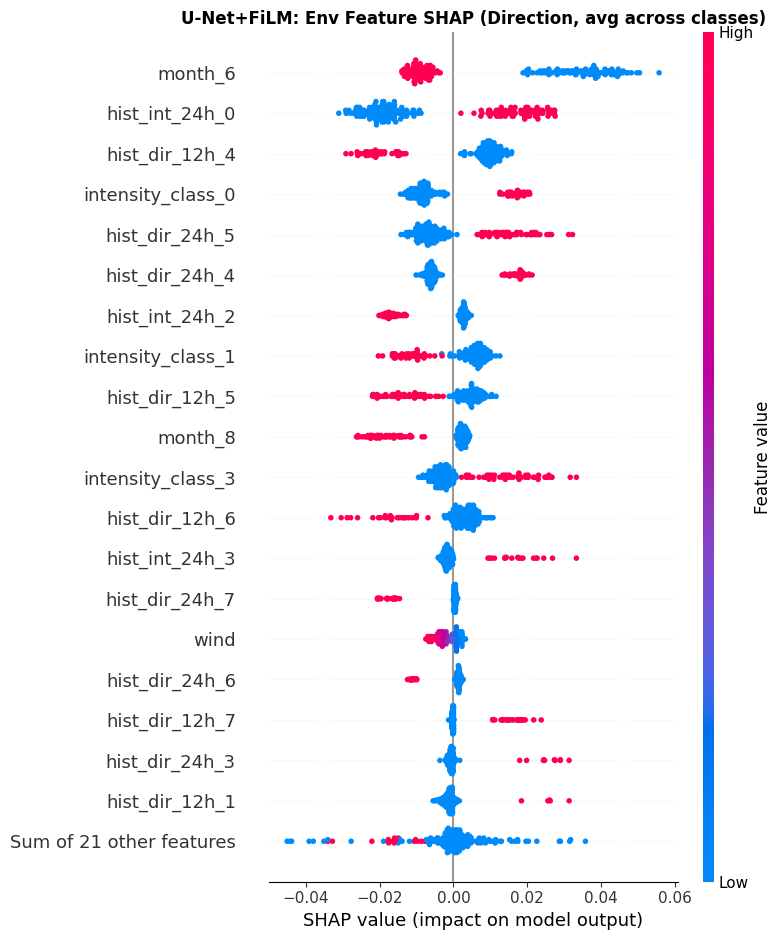

Saved: figures/shap_env_beeswarm_unet.png


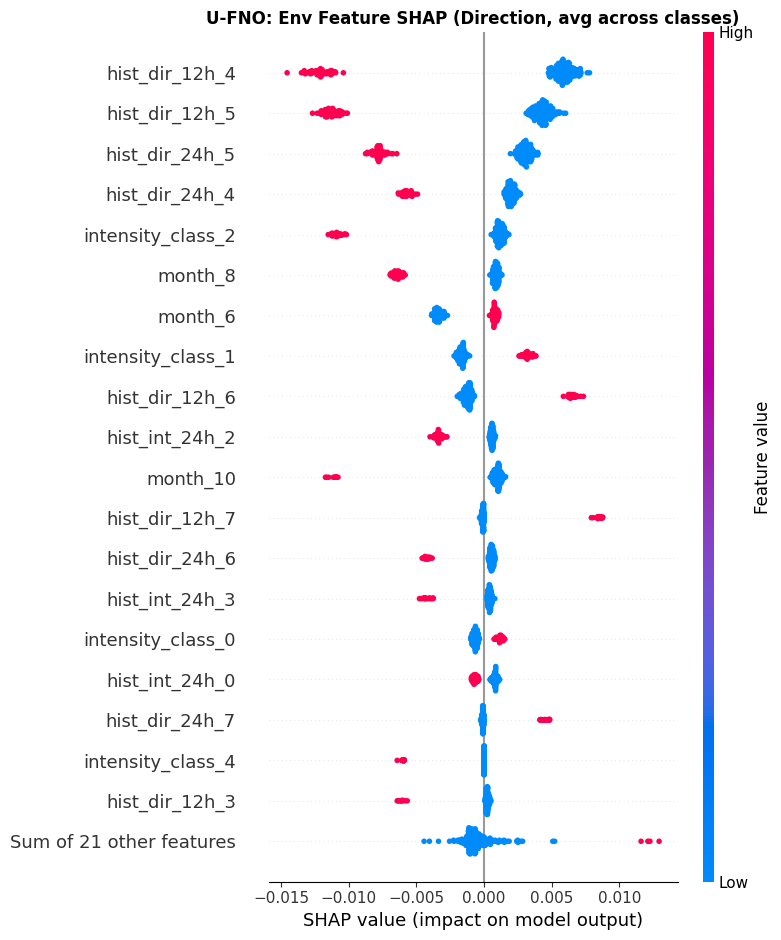

Saved: figures/shap_env_beeswarm_ufno.png


In [32]:
# - SHAP beeswarm plots (one per model, saved separately) -
ENV_FEATURE_NAMES = (
    ['wind'] +
    ['move_velocity'] +
    [f'intensity_class_{i}' for i in range(6)] +
    [f'month_{i}' for i in range(12)] +
    [f'hist_dir_12h_{i}' for i in range(8)] +
    [f'hist_dir_24h_{i}' for i in range(8)] +
    [f'hist_int_24h_{i}' for i in range(4)]
)

explain_env_np = explain_env.cpu().numpy()  # (200, 40)

# Debug: check SHAP value structure
print(f'shap_values_unet type: {type(shap_values_unet)}')
if isinstance(shap_values_unet, list):
    print(f'  list length: {len(shap_values_unet)}, element shape: {shap_values_unet[0].shape}')
elif isinstance(shap_values_unet, np.ndarray):
    print(f'  array shape: {shap_values_unet.shape}')

def get_shap_avg(shap_values):
    """Average absolute SHAP across classes, handling both list and array formats."""
    if isinstance(shap_values, list):
        return np.mean(shap_values, axis=0)  # (n_samples, n_features)
    elif shap_values.ndim == 3:
        # Shape (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
        if shap_values.shape[0] == explain_env_np.shape[0]:
            return shap_values.mean(axis=2)  # avg over classes dim
        else:
            return shap_values.mean(axis=0)  # avg over classes dim
    else:
        return shap_values  # already (n_samples, n_features)

shap_avg_unet = get_shap_avg(shap_values_unet)
shap_avg_ufno = get_shap_avg(shap_values_ufno)
print(f'shap_avg_unet shape: {shap_avg_unet.shape}, explain_env_np shape: {explain_env_np.shape}')

for shap_avg, title, fname in [
    (shap_avg_unet, 'U-Net+FiLM', 'shap_env_beeswarm_unet.png'),
    (shap_avg_ufno, 'U-FNO', 'shap_env_beeswarm_ufno.png'),
]:
    explanation = shap.Explanation(
        values=shap_avg,
        data=explain_env_np,
        feature_names=ENV_FEATURE_NAMES,
    )
    plt.figure(figsize=(10, 10))
    shap.plots.beeswarm(explanation, max_display=20, show=False)
    plt.title(f'{title}: Env Feature SHAP (Direction, avg across classes)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'figures' / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/{fname}')

In [ ]:
# -- SHAP bar plot: mean |SHAP| per env feature group, both models --
def get_shap_abs_mean(shap_values):
    """Mean absolute SHAP across classes, handling list or 3D array."""
    if isinstance(shap_values, list):
        return np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n_samples, n_features)
    elif shap_values.ndim == 3:
        return np.abs(shap_values).mean(axis=2)  # (n_samples, n_features) - avg over classes
    else:
        return np.abs(shap_values)

shap_abs_unet = get_shap_abs_mean(shap_values_unet)  # (200, 40)
shap_abs_ufno = get_shap_abs_mean(shap_values_ufno)  # (200, 40)
print(f'shap_abs shapes: unet={shap_abs_unet.shape}, ufno={shap_abs_ufno.shape}')

group_imp_unet, group_imp_ufno = {}, {}
for group_name, slc in ENV_GROUPS.items():
    group_imp_unet[group_name] = shap_abs_unet[:, slc].mean()
    group_imp_ufno[group_name] = shap_abs_ufno[:, slc].mean()

# Print values
print(f'\n{"Group":20s}  {"U-Net+FiLM":>12s}  {"U-FNO":>12s}')
print('-' * 48)
for g in ENV_GROUPS:
    print(f'{g:20s}  {group_imp_unet[g]:12.6f}  {group_imp_ufno[g]:12.6f}')

# Comparison bar chart
env_names = list(ENV_GROUPS.keys())
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(env_names))
w = 0.35

unet_vals = [group_imp_unet[g] for g in env_names]
ufno_vals = [group_imp_ufno[g] for g in env_names]

ax.bar(x - w/2, unet_vals, w, label='U-Net+FiLM', color='steelblue')
ax.bar(x + w/2, ufno_vals, w, label='U-FNO', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(env_names, rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('SHAP: Env Feature Group Importance Comparison (Direction)', fontweight='bold')
ax.legend()

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'shap_env_group_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_env_group_comparison.png')

## Section 10: Gradient-Based Grid Channel Attribution

Full SHAP on the high-dimensional grid (15, 81, 81) is computationally intractable. Instead, we
compute per-channel mean absolute gradient (`mean(|d_loss/d_input|)`) as a proxy for channel
importance. This confirms the ablation findings from a different angle.

In [34]:
# - Grid channel importance via gradient-based attribution for both models -
CH_NAMES = ['SST', 'u_200', 'u_500', 'u_850', 'u_925',
            'v_200', 'v_500', 'v_850', 'v_925',
            'z_200', 'z_500', 'z_850', 'z_925',
            'wind_shear', 'vorticity']

def compute_grid_gradient_importance(model, grids, envs, d1ds, tfs):
    """Compute per-channel mean |gradient| for direction prediction."""
    grids_dev = grids[:200].to(DEVICE).requires_grad_(True)
    envs_dev  = envs[:200].to(DEVICE)
    d1ds_dev  = d1ds[:200].to(DEVICE)
    tfs_dev   = tfs[:200].to(DEVICE)

    model.eval()
    dir_logits, _ = model(grids_dev, envs_dev, d1ds_dev, tfs_dev)
    pred_classes = dir_logits.argmax(dim=1)
    target_logits = dir_logits[torch.arange(len(pred_classes)), pred_classes]
    target_logits.sum().backward()

    grad = grids_dev.grad.detach().cpu()  # (200, 15, 81, 81)
    return grad.abs().mean(dim=(0, 2, 3))  # (15,)

ch_imp_unet = compute_grid_gradient_importance(unet_film, all_grids, all_envs, all_d1ds, all_tfs)
ch_imp_ufno = compute_grid_gradient_importance(ufno, all_grids, all_envs, all_d1ds, all_tfs)

print(f'{"Channel":12s}  {"U-Net+FiLM":>12s}  {"U-FNO":>12s}')
print('-' * 40)
for i, name in enumerate(CH_NAMES):
    print(f'{name:12s}  {ch_imp_unet[i]:12.6f}  {ch_imp_ufno[i]:12.6f}')

Channel         U-Net+FiLM         U-FNO
----------------------------------------
SST               0.000057      0.000087
u_200             0.000118      0.000081
u_500             0.000185      0.000115
u_850             0.000091      0.000070
u_925             0.000057      0.000069
v_200             0.000103      0.000084
v_500             0.000191      0.000121
v_850             0.000141      0.000092
v_925             0.000087      0.000077
z_200             0.000071      0.000066
z_500             0.000044      0.000087
z_850             0.000048      0.000066
z_925             0.000041      0.000063
wind_shear        0.000070      0.000092
vorticity         0.000058      0.000079


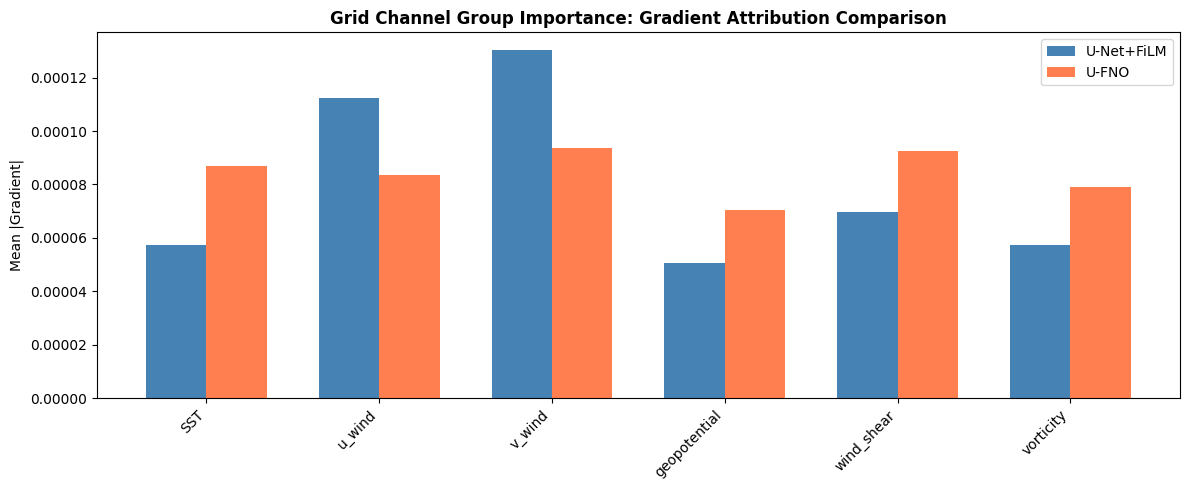

Saved: figures/gradient_grid_comparison.png


In [35]:
# - Grid channel importance grouped and plotted side by side -
grid_group_imp_unet, grid_group_imp_ufno = {}, {}
for group_name, channels in GRID_GROUPS.items():
    grid_group_imp_unet[group_name] = ch_imp_unet[channels].mean().item()
    grid_group_imp_ufno[group_name] = ch_imp_ufno[channels].mean().item()

groups = list(GRID_GROUPS.keys())
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(groups))
w = 0.35

ax.bar(x - w/2, [grid_group_imp_unet[g] for g in groups], w, label='U-Net+FiLM', color='steelblue')
ax.bar(x + w/2, [grid_group_imp_ufno[g] for g in groups], w, label='U-FNO', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=45, ha='right')
ax.set_ylabel('Mean |Gradient|')
ax.set_title('Grid Channel Group Importance: Gradient Attribution Comparison', fontweight='bold')
ax.legend()

plt.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'gradient_grid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/gradient_grid_comparison.png')